# How stale can an optical digital twin be?

A reproducible walkthrough of the OFC 2027 paper's four results. Every number is
read from the sealed / deterministic records committed in `analysis/qot/`; nothing
here re-fits or tunes. To regenerate the records from scratch (GNPy, ~minutes each):

```
python fam_qot.py   --seeds 20260825 20260826 20260827   # sealed graded (QOT)
python fam_qotml.py --seeds 20260825 20260826 20260827   # sealed graded (QOT-ML)
python qot_sweep.py                                      # deterministic (budget law)
python sndlib_fill.py && python qot_capacity.py          # deterministic (capacity)
python fam_qotflip.py --seeds 0 1 2                      # flip (seal 2026-08-27)
```

Provenance: preregs `PREREG-XPROTO-QOT*.md`, ledger `../../experiments/SEALS.md`.

In [1]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'axes.grid': True,
                     'grid.alpha': 0.3, 'figure.dpi': 110})
L = lambda f: json.load(open(f))
sweep   = L('QOT-sweep.json')
cap     = L('QOT-capacity.json')
flip    = L('QOTFLIPREP-family.json')
ml      = L('XPROTO-QOT-ML-graded.json')
paths   = L('QOT-paths.json')
print('records loaded')

records loaded


## 1. The freshness budget

The twin's view is synced at provisioning (6 channels). As the band fills toward 76,
its format decisions false-clear. The rate is linear in the number of un-synced adds,
and the 5% risk target gives a budget of about 8 adds.

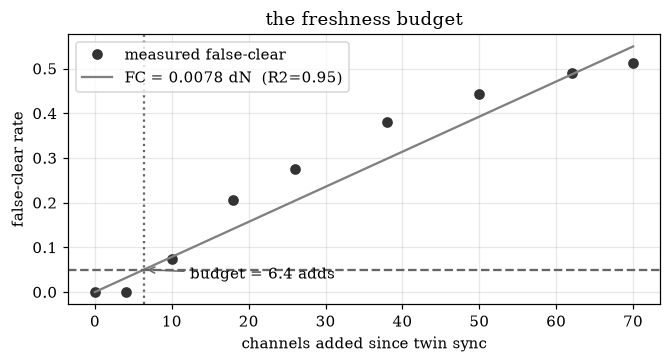

In [2]:
dn = np.array(sweep['fill']) - sweep['fill'][0]   # channels added since sync
fc = np.array(sweep['fc_curve'])
k, r2 = sweep['fc_vs_dn_slope'], sweep['fc_vs_dn_r2']
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(dn, fc, 'o', ms=6, color='0.2', label='measured false-clear')
xs = np.linspace(0, dn.max(), 50)
ax.plot(xs, k * xs, '-', color='0.5', label=f'FC = {k:.4f} dN  (R2={r2:.2f})')
ax.axhline(0.05, ls='--', color='0.4'); ax.axvline(0.05/k, ls=':', color='0.4')
ax.annotate(f'budget = {0.05/k:.1f} adds', (0.05/k, 0.05), (0.05/k+6, 0.03),
            arrowprops=dict(arrowstyle='->', color='0.4'))
ax.set_xlabel('channels added since twin sync'); ax.set_ylabel('false-clear rate')
ax.set_title('the freshness budget'); ax.legend(); plt.tight_layout(); plt.show()

## 2. Who is exposed when the twin is stale

Per-service false-clears over the footprint (spectral position, reach), from the
sealed graded per-lightpath record. Exposure concentrates near format boundaries.
On real SNDlib janos-us-ca fill, a per-lightpath twin recovers ~8% spectral
efficiency over a uniform margin at matched safety.

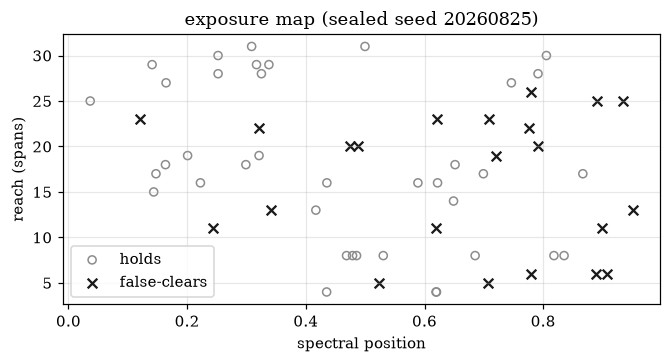

capacity vs uniform margin (real SNDlib fill): +8.0% (0.334 b/sym, ~21.4 Gb/s/ch) at FC<=0.01


In [3]:
recs = paths['records']
pos  = np.array([r['position'] for r in recs]); reach = np.array([r['reach'] for r in recs])
naiv = np.array([r['naive_fail'] for r in recs], bool)
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.scatter(pos[~naiv], reach[~naiv], marker='o', s=28, facecolors='none',
           edgecolors='0.55', label='holds')
ax.scatter(pos[naiv], reach[naiv], marker='x', s=40, color='0.1', label='false-clears')
ax.set_xlabel('spectral position'); ax.set_ylabel('reach (spans)')
ax.set_title('exposure map (sealed seed 20260825)'); ax.legend()
plt.tight_layout(); plt.show()
print(f"capacity vs uniform margin (real SNDlib fill): +{cap['recovered_pct']}% "
      f"({cap['recovered_bpersym']} b/sym, ~{cap['recovered_gbps_per_channel']} Gb/s/ch) "
      f"at FC<={cap['target_fc']}")

## 3. One twin, two consumers, opposite verdicts (the Flip)

Two margin policies with the same 1.0 dB fleet-mean budget. Policy A allocates by
reach, policy B by band-centrality. The reach-reading fleet prefers A, the
position-reading fleet prefers B, on every seed. The FEC-class control (same read
projection, shifted thresholds) shows no inversion, exactly as the alignment
taxonomy predicts. Shakedown record; sealed grading 2026-08-27.

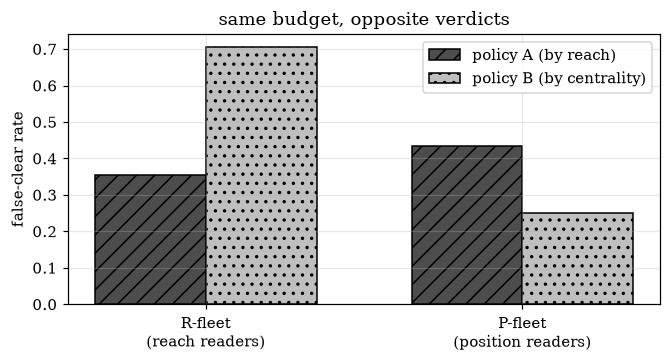

seed 0: flip=True  fec-null holds=True
seed 1: flip=True  fec-null holds=True
seed 2: flip=True  fec-null holds=True


In [4]:
cells = flip['cells']
labels = ['R-fleet\n(reach readers)', 'P-fleet\n(position readers)']
A = [np.mean([c['fp_fc_R_A'] for c in cells]), np.mean([c['fp_fc_P_A'] for c in cells])]
B = [np.mean([c['fp_fc_R_B'] for c in cells]), np.mean([c['fp_fc_P_B'] for c in cells])]
x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.bar(x - w/2, A, w, color='0.3', hatch='//', edgecolor='k', label='policy A (by reach)')
ax.bar(x + w/2, B, w, color='0.75', hatch='..', edgecolor='k', label='policy B (by centrality)')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('false-clear rate')
ax.set_title('same budget, opposite verdicts')
ax.legend(); plt.tight_layout(); plt.show()
for c in cells:
    print(f"seed {c['seed']}: flip={c['fp_flip']}  fec-null holds={not c['fec_flip']}")

## 4. The learned surrogate fails at the threshold

Sealed graded result (XPROTO-QOT-ML). The average-error surrogate wins MAE and
false-clears five times more at the FEC cliff than the quantile objective, at equal
delivered capacity. Quantile QoT models are prior art (Panayiotou et al.); the
measured dissociation is the price of not using them.

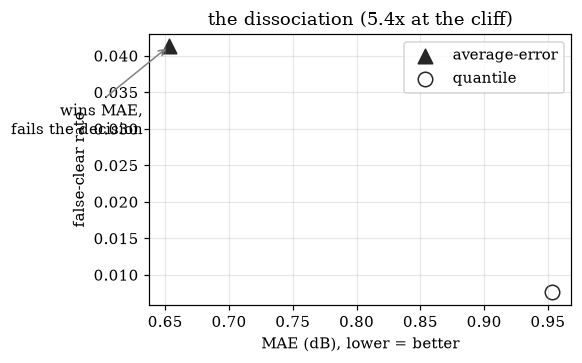

sealed verdict: PASS  seeds [20260825, 20260826, 20260827]


In [5]:
cells = ml['cells']
mae_m = np.mean([c['mae_mse'] for c in cells]);  mae_a = np.mean([c['mae_aware'] for c in cells])
fc_m  = np.mean([c['fc_mse'] for c in cells]);   fc_a  = np.mean([c['fc_aware'] for c in cells])
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.scatter([mae_m], [fc_m], marker='^', s=90, color='0.15', label='average-error')
ax.scatter([mae_a], [fc_a], marker='o', s=90, facecolors='white', edgecolors='0.15',
           label='quantile')
ax.annotate('wins MAE,\nfails the decision', (mae_m, fc_m), (mae_m-0.02, fc_m-0.012),
            ha='right', arrowprops=dict(arrowstyle='->', color='0.5'))
ax.set_xlabel('MAE (dB), lower = better'); ax.set_ylabel('false-clear rate')
ax.set_title(f'the dissociation ({fc_m/fc_a:.1f}x at the cliff)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'sealed verdict: {ml["verdict"]}  seeds {ml["seeds"]}')

---
*Every figure above reads committed records. The sealed cells refuse to grade
without their prereg seal; see `qot_check.py` / `qotml_check.py` /
`qotflip_check.py` and the campaign ledger for the verification chain.*